# Estimate the contribution of the integral constraint to the window matrix:

Following Chaussidon et al. 2024 (https://arxiv.org/abs/2411.17623). 

Note: For now the geometrical part of the window does not contain the wide-angle effects, so it also account for it !

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from clustering_statistics.tools import get_stats_fn

from tools import read_data, rebin_data

plt.style.use('ec_style.mplstyle')   

In [11]:
def compute_integral_constraint_contribution(stats_dir, project, data_dir, tracer, region, zrange, ellsin=[0, 2], initial_params=None, ncall=5, hard_limits=False):
    from integral_constraints import WindowIC
    from clustering_statistics.tools import get_stats_fn
    import lsstypes 

    weight = 'default-fkp-oqe'
    print(f'Load mocks for covariance with : {weight=}')
    fns_cov = [get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum_poles', tracer=tracer, region=region, zrange=zrange, 
                                    weight=weight, imock=imock) for imock in range(1000)]
    for i, bad_mocks in enumerate([363, 565]):
        _ = fns_cov.pop(bad_mocks - i)  # don't forget pop remove the object from the list, so the next bad_mocks index is shifted by -1.
    pks_cov = [lsstypes.read(fn) for fn in fns_cov]

    weight = 'default-noimsys-fkp-oqe_reshuffle'
    print(f'Load mocks without IC with : {weight=}')
    fns_noric_noaic = [get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum_poles', tracer=tracer, region=region, zrange=zrange, 
                                    weight=weight, imock=imock) for imock in range(70)]
    pks_noric_noaic = [lsstypes.read(fn) for fn in fns_noric_noaic]

    weight = 'default-fkp-oqe'
    print(f'Load mocks with IC with : {weight=}')
    fns = [get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum_poles', tracer=tracer, region=region, zrange=zrange, 
                                    weight=weight, imock=imock) for imock in range(70)]
    pks = [lsstypes.read(fn) for fn in fns]

    print('Load Window Matrix:')
    _, wmatrix, _ = read_data(stats_dir=data_dir, tracer=tracer, zrange=zrange, weight_type='default-fkp-oqe', region=region)

    # Estimate the IC contribution and build the window matrix with IC:
    IC = WindowIC(wmatrix, pks_noric_noaic, pks, pks_cov, ellsin=ellsin)

    _ = IC.fit(ncall=ncall, initial_params=initial_params, hard_limits=hard_limits)
    print('Best fit parameters: ', IC.bestfit_params)
    
    fn_wm_ic = get_stats_fn(stats_dir=data_dir, tracer=tracer, zrange=zrange, weight=weight, region=region, kind='window_mesh2_spectrum', extra='with_ic')
    print(fn_wm_ic)
    _ = IC.build_wmatrix_with_ic(save_fn=fn_wm_ic)

    IC.plot_validation()

LRGxELGnotqso (0.8, 1.1) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-fkp-oqe'
Load Window Matrix:
Reading the window without integral constraint contribution...
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:01<00:00,  5.23it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1555                       │             Nfcn = 4112              │
│ EDM = 2.29e-06 (Goal: 0.0002)    │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [0.4771526803584081, 0.999

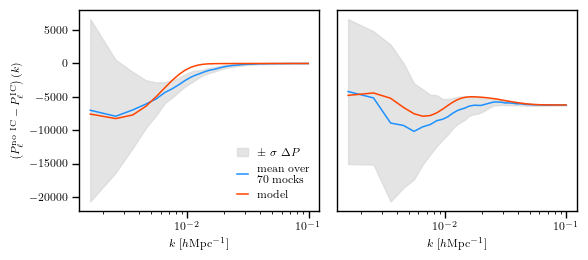

LRGxELGnotqso (0.8, 1.1) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-fkp-oqe'
Load Window Matrix:
Reading the window without integral constraint contribution...
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:00<00:00, 12.00it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2245                       │             Nfcn = 1698              │
│ EDM = 4.77e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [1.0, 8.00219312901973e-06

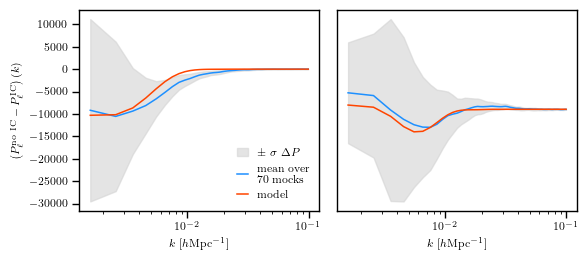

ELGnotqsoxQSO (0.8, 1.6) NGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-fkp-oqe'
Load Window Matrix:
Reading the window without integral constraint contribution...
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:00<00:00, 10.86it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1680                       │             Nfcn = 1944              │
│ EDM = 6.17e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [0.2791819331685641, 8.909

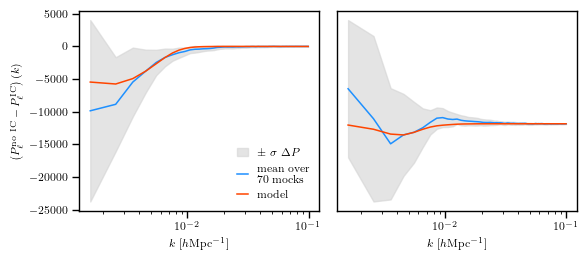

ELGnotqsoxQSO (0.8, 1.6) SGC
Load mocks for covariance with : weight='default-fkp-oqe'
Load mocks without IC with : weight='default-noimsys-fkp-oqe_reshuffle'
Load mocks with IC with : weight='default-fkp-oqe'
Load Window Matrix:
Reading the window without integral constraint contribution...
ncall=10, initial_params=[1e-05, 0, 0, 0, 1, 1, 1, 1]


100%|██████████| 10/10 [00:01<00:00,  7.43it/s]


Valid minimum? True
Valid minimum? True
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1840                       │             Nfcn = 2476              │
│ EDM = 0.000126 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
Best fit parameters:  [0.9997852498411692, -6.44

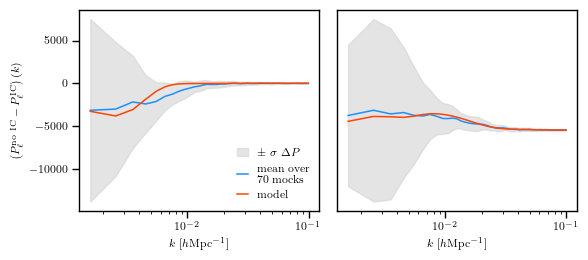

In [13]:
stats_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/'
project = 'local_png/base/holi-v3-altmtl/'

data_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/'

tracers = ['LRG', 'QSO', 'ELGnotqso', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO'][3:4]
zranges = {'LRG': [(0.4, 1.1)], 'QSO': [(0.8, 3.5)], 'ELGnotqso': [(0.8, 1.6)], 
           'LRGxQSO': [(0.8, 1.1)], 'LRGxELGnotqso': [(0.8, 1.1)], 'ELGnotqsoxQSO': [(0.8, 1.6)]}

#regions = {tracer: ['GCcomb'] for tracer in tracers} 

regions = {tracer: ['NGC', 'SGC'] for tracer in tracers} 

for tracer in tracers:
    for zrange in zranges[tracer]:
        for region in regions[tracer]:
            print(tracer, zrange, region)

            if tracer in ['LRG', 'QSO', 'ELGnotqso']:
                if tracer == 'LRG':
                    if region == 'GCcomb':
                        initial_params = [1e-4,0,1e-4,0]+[1,1,1,1]
                    else:
                        initial_params = [1e-4,0,1e-6,0]+[1,1,1,1]
                else: 
                    initial_params = [1e-4,0,0,0]+[1,1,1,1]
                ncall = 5 
                hard_limits = False
                
            else:
                if tracer == 'LRGxQSO':
                    initial_params = [1e-4,0,0,0]+[1,1,1,1]
                else:
                    initial_params = [1e-5,0,0,0]+[1,1,1,1]
                ncall = 10
                hard_limits = True

            compute_integral_constraint_contribution(stats_dir, project, data_dir, tracer, region, zrange, 
                                                     ellsin=[0, 2], initial_params=initial_params, ncall=ncall, hard_limits=hard_limits)
